In [3]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import uniform

## MC error propagation

Little illustration of MC application in data analysis

We have $x = 0.1 \pm 0.1$, what is the error of $y = \sqrt[3]{x}$? Assume a normal distribution of $x$. Calculate the 95% confidence interval ($\pm 2\sigma$ for a normal distribution).

In [4]:
x_mean = 0.1
x_std = 0.1
def f(x): return np.cbrt(x)

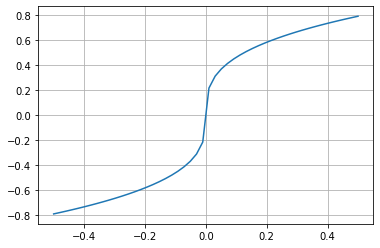

In [5]:
x = np.linspace(-.5, .5)
plt.plot(x, f(x))
plt.grid()

In [6]:
from numpy.random import normal

In [7]:
nsampl = 10000
xsampl = normal(x_mean, x_std, nsampl)
ysampl = f(xsampl)

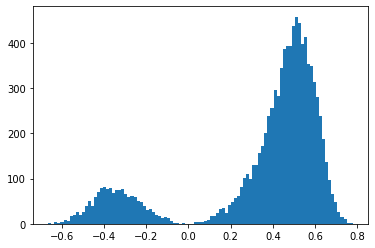

In [8]:
plt.hist(ysampl, bins=100);

In [12]:
Q0, Q1, Q2 = np.quantile(ysampl,[0.025, 0.5, 0.975])
print("y = %.2f, CI = (%.2f, %.2f)"%(Q1, Q0, Q2))

y = 0.46, CI = (-0.45, 0.67)


Porovnejme s analytickým výpočtem

In [10]:
def dfdx(x): return x**(-2/3)*1/3
# y_std = dfdx(x_mean) * x_std
y_std = dfdx(x_mean) * x_std
y_mean = f(x_mean)

In [13]:
G0, G1, G2 = y_mean - 2*y_std,y_mean, y_mean + 2*y_std
print("y = %.2f, CI = (%.2f, %.2f)"%(G1, G0, G2))

y = 0.46, CI = (0.15, 0.77)


In [38]:
y_mean - 2*y_std, y_mean + 2*y_std

(0.15471962778709264, 0.7735981389354631)

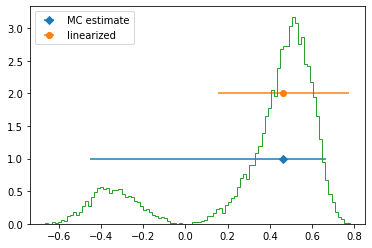

In [17]:
plt.errorbar([Q1], 1, xerr=np.array([[Q1-Q0], [Q2-Q1]]), fmt="D", label="MC estimate")
plt.errorbar([G1], 2, xerr=np.array([[G1-G0], [G2-G1]]), fmt="o", label="linearized")
plt.hist(ysampl, bins=100, density=True, histtype="step");
plt.legend(loc="upper left")